<a href="https://colab.research.google.com/github/luiza-bryn/experimentos-rede-neurais/blob/main/rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 2 — Redes Neurais
**Disciplina:** Sistemas Inteligentes — INE/UFSC  
**Aluna:** Luiza Bryn

---
**Estrutura do notebook:**
1. Configuração e carregamento dos dados
2. Tópico 1 — MLP simples
3. Tópico 2 — CNN com Data Augmentation
4. Tópico 3 — Busca de Hiperparâmetros
5. Tópico 4 — Avaliação final no conjunto de teste

## 0. Configuração e carregamento dos dados

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import itertools

In [4]:
# Carrega CIFAR-10 e normaliza os pixels para [0, 1]
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Separa 10 % do treino como validação
val_split = int(len(x_train) * 0.1)
x_val, y_val     = x_train[:val_split], y_train[:val_split]
x_train, y_train = x_train[val_split:], y_train[val_split:]

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Treino : {x_train.shape}  Validação: {x_val.shape}  Teste: {x_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 424s 2us/step
Treino : (45000, 32, 32, 3)  Validação: (5000, 32, 32, 3)  Teste: (10000, 32, 32, 3)


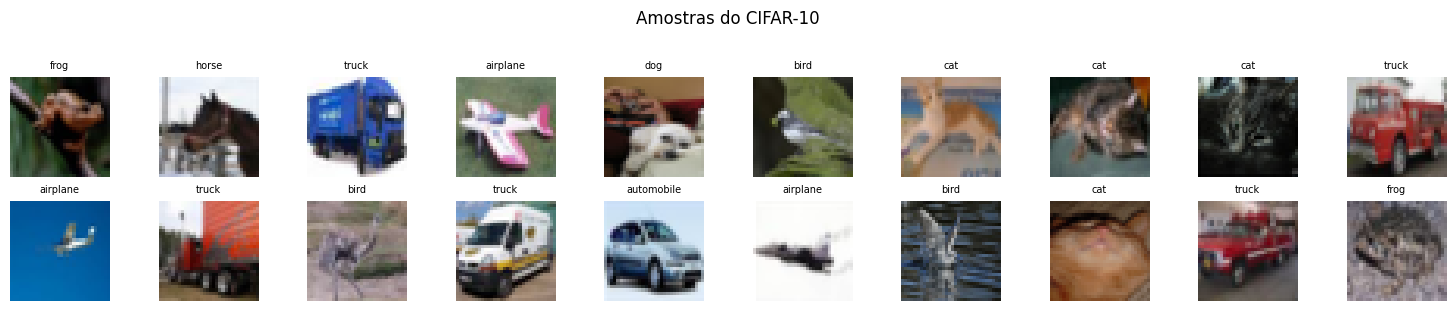

In [ ]:
# Visualiza algumas amostras
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i][0]], fontsize=7)
    ax.axis('off')
plt.suptitle('Amostras do CIFAR-10', y=1.02)
plt.tight_layout()
plt.show()

### Função auxiliar para plotar loss e acurácia

In [5]:
def plot_history(history, title=''):
    """Plota loss e acurácia de treino e validação por época."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'],     label='Treino')
    ax1.plot(history.history['val_loss'], label='Validação')
    ax1.set_title(f'{title} — Loss por época')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss (categorical crossentropy)')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['accuracy'],     label='Treino')
    ax2.plot(history.history['val_accuracy'], label='Validação')
    ax2.set_title(f'{title} — Acurácia por época')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Acurácia')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

---
## Tópico 1 — MLP Simples (sem camadas convolucionais)

A MLP recebe a imagem 32×32×3 achatada como vetor de entrada (3072 valores).  
Camadas densas aprendem relações entre pixels, mas **sem** explorar a estrutura espacial da imagem.

In [12]:
def build_mlp(units_list=(512, 256), dropout=0.3):
    """Constrói uma MLP com número variável de camadas ocultas."""
    model = models.Sequential(name='MLP')
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Flatten())
    for units in units_list:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation='softmax'))
    return model

mlp = build_mlp(units_list=(512, 256, 128), dropout=0.3)
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2133 - loss: 2.0930 - val_accuracy: 0.3062 - val_loss: 1.8996
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2744 - loss: 1.9476 - val_accuracy: 0.3406 - val_loss: 1.8642
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2930 - loss: 1.9078 - val_accuracy: 0.3470 - val_loss: 1.8492
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3096 - loss: 1.8776 - val_accuracy: 0.3606 - val_loss: 1.7970
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3177 - loss: 1.8581 - val_accuracy: 0.3558 - val_loss: 1.8224
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3310 - loss: 1.8347 - val_accuracy: 0.3806 - val_loss: 1.7400
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3371 - loss: 1.8177 - val_accuracy: 0.3674 - val_loss: 1.7527
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3445 - loss: 1.8034 - val_accuracy: 0

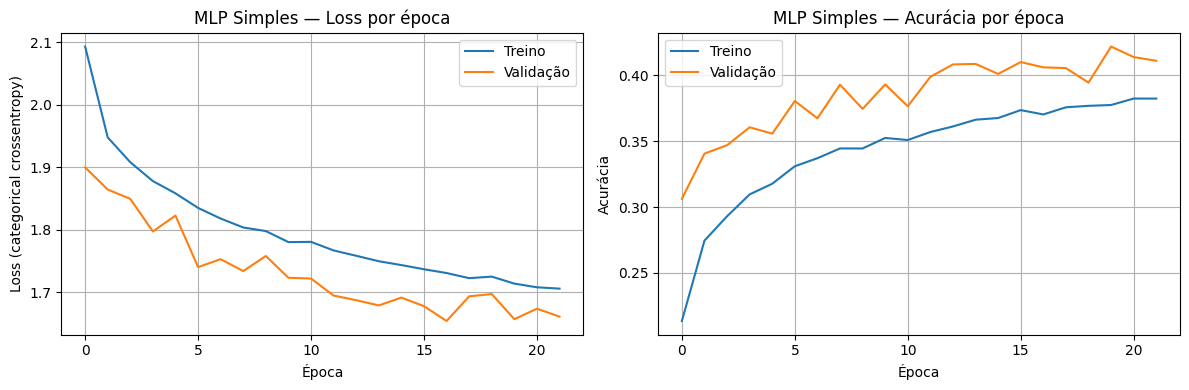


MLP — Loss validação: 1.6537 | Acurácia validação: 0.4062


In [14]:
plot_history(history_mlp, title='MLP Simples')

val_loss_mlp, val_acc_mlp = mlp.evaluate(x_val, y_val, verbose=0)
print(f'\nMLP — Loss validação: {val_loss_mlp:.4f} | Acurácia validação: {val_acc_mlp:.4f}')

### Análise — Tópico 1

**Por que acurácia e loss não são proporcionais?**  
- A **loss** (categorical crossentropy) penaliza a confiança das predições: uma previsão correta com baixa probabilidade aumenta muito a loss, enquanto uma previsão errada com margem estreita a aumenta pouco. Já a **acurácia** considera apenas se a classe mais provável é a correta — ignora a margem.  
- Portanto, é possível que a loss diminua enquanto a acurácia permanece a mesma (o modelo está mais calibrado, mas não erra menos classes), ou que a acurácia suba enquanto a loss sobe (o modelo acerta mais, mas com maior confiança errada em alguns exemplos).

**Os resultados indicam desempenho satisfatório?**  
- Dado que uma escolha aleatória daria 10%, o modelo aprende algo útil. Mas não é satisfatório uma taxa de mnos de 50% em aprendizados de máquina.
- A MLP é particularmente suscetível a overfitting, porque trata pixels independentemente, sem capturar estrutura espacial.

---
## Tópico 2 — CNN com Data Augmentation

A CNN extrai características locais (bordas, texturas) com camadas convolucionais.  
O **data augmentation** gera variações artificiais das imagens de treino (flip, crop, brilho),  
reduzindo overfitting quando a quantidade de dados por classe é limitada.

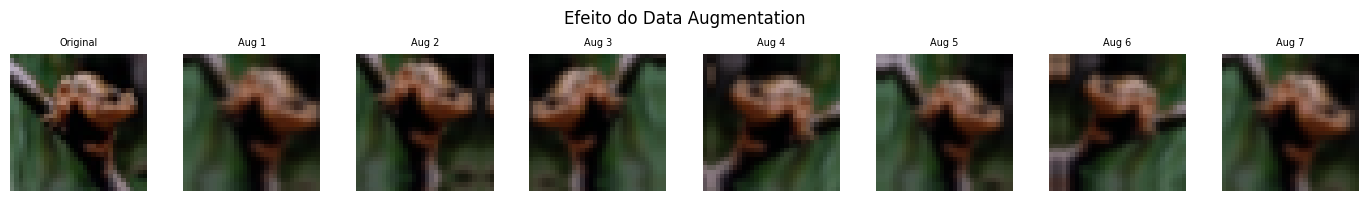

In [15]:
# Opção 1: Remover RandomBrightness (mais seguro)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

# Visualiza o efeito do augmentation
sample = x_train[:1]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
axes[0].imshow(sample[0])
axes[0].set_title('Original', fontsize=7)
axes[0].axis('off')

for i in range(1, 8):
    aug = data_augmentation(sample, training=True)
    aug_img = aug[0].numpy()
    aug_img = np.clip(aug_img, 0, 1)
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}', fontsize=7)
    axes[i].axis('off')

plt.suptitle('Efeito do Data Augmentation')
plt.tight_layout()
plt.show()

In [16]:
def build_cnn():
    inputs = keras.Input(shape=(32, 32, 3))

    # Augmentation embutido — ativo só no treino
    x = data_augmentation(inputs)

    # Bloco 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # Bloco 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Bloco 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Classificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN_Augmentation')

cnn = build_cnn()
cnn.summary()

Model: "CNN_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,57

 Total params: 176,298 (688.66 KB)

 Trainable params: 175,658 (686.16 KB)

 Non-trainable params: 640 (2.50 KB)

In [17]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = cnn.fit(
    x_train, y_train,
    epochs=80,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop_cnn, lr_scheduler],
    verbose=1
)

Epoch 1/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3471 - loss: 1.7810 - val_accuracy: 0.1948 - val_loss: 2.8037 - learning_rate: 0.0010
Epoch 2/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4604 - loss: 1.4870 - val_accuracy: 0.5330 - val_loss: 1.2846 - learning_rate: 0.0010
Epoch 3/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5164 - loss: 1.3496 - val_accuracy: 0.5386 - val_loss: 1.2826 - learning_rate: 0.0010
Epoch 4/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5480 - loss: 1.2669 - val_accuracy: 0.5142 - val_loss: 1.4518 - learning_rate: 0.0010
Epoch 5/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5741 - loss: 1.2034 - val_accuracy: 0.4838 - val_loss: 1.7352 - learning_rate: 0.0010
Epoch 6/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5920 - loss: 1.1473 - val_accuracy: 0.5758 - val_loss: 1.2394 - learning_rate: 0.0010
Epoch 7/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6075 - l

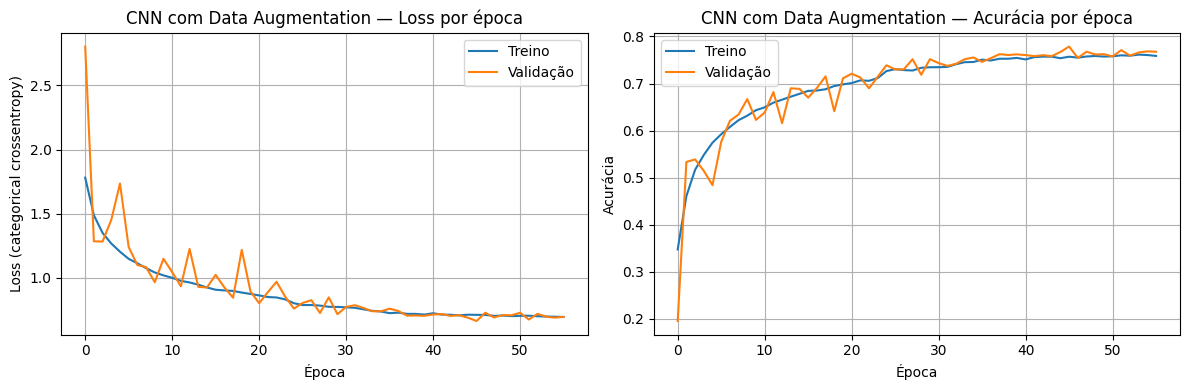


CNN — Loss validação: 0.6626 | Acurácia validação: 0.7786


In [18]:
plot_history(history_cnn, title='CNN com Data Augmentation')

val_loss_cnn, val_acc_cnn = cnn.evaluate(x_val, y_val, verbose=0)
print(f'\nCNN — Loss validação: {val_loss_cnn:.4f} | Acurácia validação: {val_acc_cnn:.4f}')

### Análise — Tópico 2

**Indicação do uso de Data Augmentation:**  
O CIFAR-10 possui apenas 5 000 imagens por classe no treino. Redes convolucionais tendem a memorizar os dados de treino. O data augmentation multiplica artificialmente a diversidade dos exemplos simulando um dataset maior sem coleta de novos dados.

**Os resultados indicam desempenho satisfatório?**  
- A CNN com augmentation supera a MLP consideravelmente, dada sua acurácia de 76%.  
- As curvas de treino e validação convergem de forma mais próxima do que na MLP, indicando melhor generalização.

---
## Tópico 3 — Busca de Hiperparâmetros

São testadas combinações de:
- **Learning rate**: 1e-3, 5e-4
- **Dropout**: 0.2, 0.4
- **Número de filtros base** (bloco 1/2/3 com proporção ×2): 32, 64

Total: 2 × 2 × 2 = **8 combinações**. Cada modelo treina por até 30 épocas com early stopping.

In [6]:
def build_cnn_hp(base_filters=32, dropout=0.3, learning_rate=1e-3):
    """CNN parametrizada para busca de hiperparâmetros."""
    aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    inputs = keras.Input(shape=(32, 32, 3))
    x = aug(inputs)

    for filters in [base_filters, base_filters * 2, base_filters * 4]:
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(dropout)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout + 0.1)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


learning_rates  = [1e-3, 5e-4]
dropouts        = [0.2, 0.4]
base_filters_list = [32, 64]

results = []

for lr, dr, bf in itertools.product(learning_rates, dropouts, base_filters_list):
    print(f'\n>>> lr={lr}  dropout={dr}  base_filters={bf}')
    tf.keras.backend.clear_session()

    model = build_cnn_hp(base_filters=bf, dropout=dr, learning_rate=lr)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    hist = model.fit(
        x_train, y_train,
        epochs=30,
        batch_size=128,
        validation_data=(x_val, y_val),
        callbacks=[es],
        verbose=0
    )

    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    n_epochs = len(hist.history['loss'])
    print(f'    val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  épocas={n_epochs}')

    results.append({
        'learning_rate': lr,
        'dropout': dr,
        'base_filters': bf,
        'val_accuracy': round(val_acc, 4),
        'val_loss': round(val_loss, 4),
        'epocas': n_epochs
    })

print('\n=== Busca concluída ===')


>>> lr=0.001  dropout=0.2  base_filters=32
    val_acc=0.8278  val_loss=0.5004  épocas=30

>>> lr=0.001  dropout=0.2  base_filters=64
    val_acc=0.8466  val_loss=0.4676  épocas=17

>>> lr=0.001  dropout=0.4  base_filters=32
    val_acc=0.7902  val_loss=0.6127  épocas=30

>>> lr=0.001  dropout=0.4  base_filters=64
    val_acc=0.8552  val_loss=0.4386  épocas=30

>>> lr=0.0005  dropout=0.2  base_filters=32
    val_acc=0.8202  val_loss=0.5324  épocas=30

>>> lr=0.0005  dropout=0.2  base_filters=64
    val_acc=0.8380  val_loss=0.4530  épocas=21

>>> lr=0.0005  dropout=0.4  base_filters=32
    val_acc=0.7804  val_loss=0.6310  épocas=30

>>> lr=0.0005  dropout=0.4  base_filters=64
    val_acc=0.7124  val_loss=0.8326  épocas=12

=== Busca concluída ===


In [7]:
df_results = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
df_results.index = range(1, len(df_results) + 1)
display(df_results)

best = df_results.iloc[0]
print(f'\nMelhor combinação encontrada:')
print(f'  learning_rate = {best["learning_rate"]}')
print(f'  dropout       = {best["dropout"]}')
print(f'  base_filters  = {best["base_filters"]}')
print(f'  val_accuracy  = {best["val_accuracy"]}')
print(f'  val_loss      = {best["val_loss"]}')

,learning_rate,dropout,base_filters,val_accuracy,val_loss,epocas
1,0.0010,0.4,64,0.8552,0.4386,30
2,0.0010,0.2,64,0.8466,0.4676,17
3,0.0005,0.2,64,0.8380,0.4530,21
4,0.0010,0.2,32,0.8278,0.5004,30
5,0.0005,0.2,32,0.8202,0.5324,30
6,0.0010,0.4,32,0.7902,0.6127,30
7,0.0005,0.4,32,0.7804,0.6310,30
8,0.0005,0.4,64,0.7124,0.8326,12



Melhor combinação encontrada:
  learning_rate = 0.001
  dropout       = 0.4
  base_filters  = 64.0
  val_accuracy  = 0.8552
  val_loss      = 0.4386


### Análise — Tópico 3

**Parâmetros e seu impacto esperado:**

| Hiperparâmetro | Impacto |
|---|---|
| **Learning rate** | Taxa de aprendizado muito alta causa instabilidade; muito baixa, convergência lenta. |
| **Dropout** | Regularização que previne overfitting desativando neurônios aleatoriamente. Dropout alto demais pode causar underfitting. |
| **Número de filtros** | Mais filtros aumentam a capacidade de representação, mas elevam o custo computacional e o risco de overfitting com dados limitados. |

**Observações gerais:**  
- O impacto da arquitetura (número de filtros) tende a superar o do dropout sozinho, pois determina a capacidade expressiva do modelo.  
- Learning rates menores costumam convergir mais suavemente, porém precisam de mais épocas.  
- A combinação vencedora Learning rate = 0.0010	Dropout = 0.4	Filtros = 64 será usada a seguir


---
## Tópico 4 — Avaliação Final no Conjunto de Teste

Retreina o melhor modelo encontrado (desta vez usando treino + validação) e avalia no conjunto de teste.

In [8]:
best_lr = best['learning_rate']
best_dr = best['dropout']
best_bf = int(best['base_filters'])

print(f'Retreinando com lr={best_lr}, dropout={best_dr}, base_filters={best_bf}')

# Concatena treino + validação para o treino final
x_train_full = np.concatenate([x_train, x_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

tf.keras.backend.clear_session()
best_model = build_cnn_hp(base_filters=best_bf, dropout=best_dr, learning_rate=best_lr)

es_final = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
lr_sched  = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history_final = best_model.fit(
    x_train_full, y_train_full,
    epochs=60,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es_final, lr_sched],
    verbose=1
)

Retreinando com lr=0.001, dropout=0.4, base_filters=64
Epoch 1/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.3985 - loss: 1.6684 - val_accuracy: 0.2084 - val_loss: 2.8769 - learning_rate: 0.0010
Epoch 2/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.5358 - loss: 1.3031 - val_accuracy: 0.5242 - val_loss: 1.3453 - learning_rate: 0.0010
Epoch 3/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.5943 - loss: 1.1500 - val_accuracy: 0.5260 - val_loss: 1.3759 - learning_rate: 0.0010
Epoch 4/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.6378 - loss: 1.0369 - val_accuracy: 0.6768 - val_loss: 0.9135 - learning_rate: 0.0010
Epoch 5/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6707 - loss: 0.9476 - val_accuracy: 0.6702 - val_loss: 0.9816 - learning_rate: 0.0010
Epoch 6/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6920 - loss: 0.8899 - val_accuracy: 0.6930 - val_loss: 0.9477 - learning_rate: 0.0010
Epoch 7/60
352/352 ━━

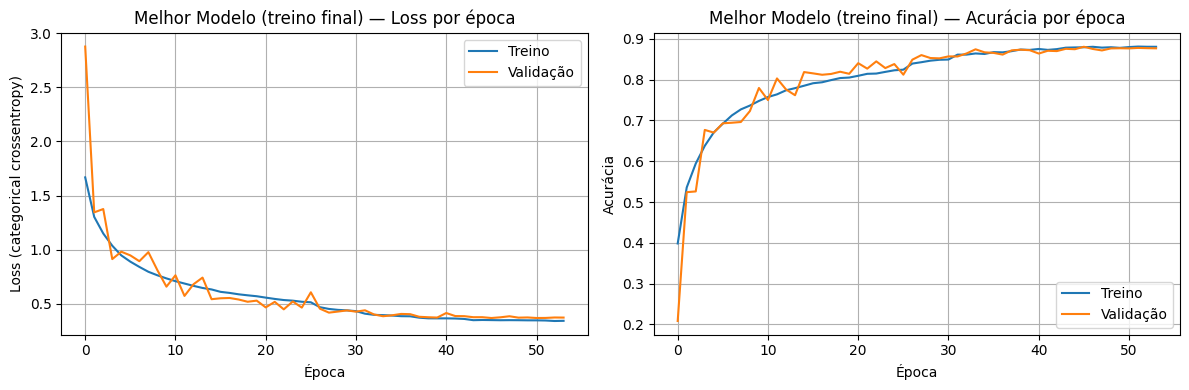


=== RESULTADO FINAL NO CONJUNTO DE TESTE ===
Loss (test) : 0.4081
Acurácia (test): 0.8685  (86.85 %)


In [9]:
plot_history(history_final, title='Melhor Modelo (treino final)')

test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f'\n=== RESULTADO FINAL NO CONJUNTO DE TESTE ===')
print(f'Loss (test) : {test_loss:.4f}')
print(f'Acurácia (test): {test_acc:.4f}  ({test_acc*100:.2f} %)')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


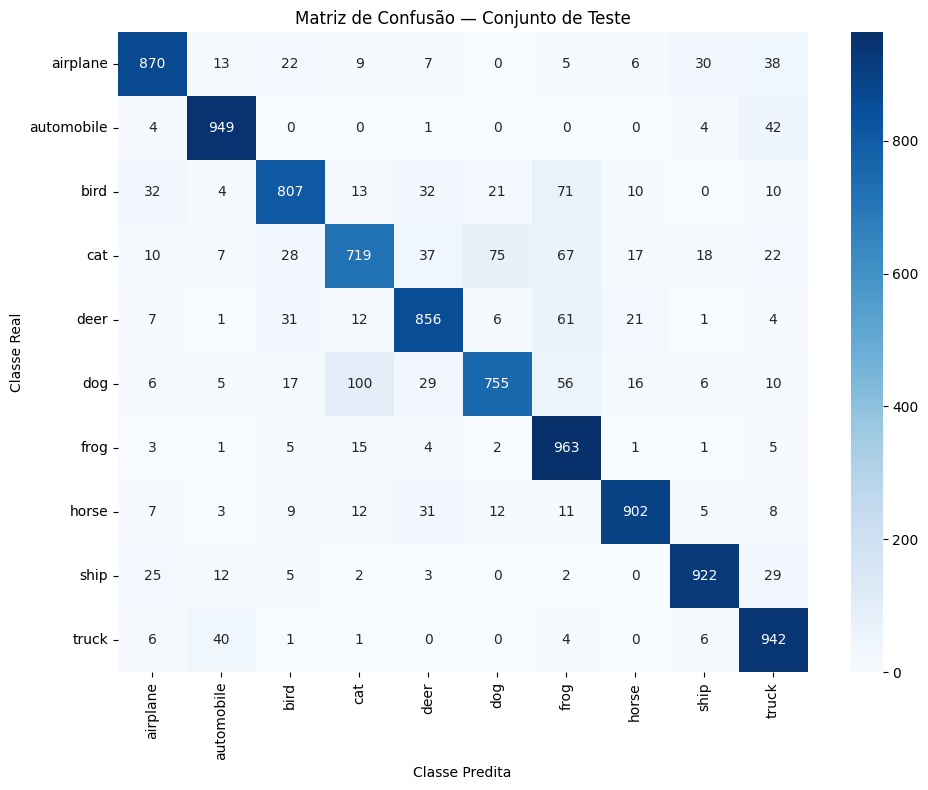


Relatório de Classificação:
              precision    recall  f1-score   support

    airplane       0.90      0.87      0.88      1000
  automobile       0.92      0.95      0.93      1000
        bird       0.87      0.81      0.84      1000
         cat       0.81      0.72      0.76      1000
        deer       0.86      0.86      0.86      1000
         dog       0.87      0.76      0.81      1000
        frog       0.78      0.96      0.86      1000
       horse       0.93      0.90      0.91      1000
        ship       0.93      0.92      0.93      1000
       truck       0.85      0.94      0.89      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(best_model.predict(x_test), axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusão — Conjunto de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.tight_layout()
plt.show()

print('\nRelatório de Classificação:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [19]:
# Tabela comparativa final entre os três modelos
mlp_test_loss, mlp_test_acc = mlp.evaluate(x_test, y_test, verbose=0)
cnn_test_loss, cnn_test_acc = cnn.evaluate(x_test, y_test, verbose=0)

comparativo = pd.DataFrame([
    {'Modelo': 'MLP Simples (Tópico 1)',
     'Acurácia Teste': f'{mlp_test_acc:.4f}',
     'Loss Teste': f'{mlp_test_loss:.4f}'},
    {'Modelo': 'CNN + Augmentation (Tópico 2)',
     'Acurácia Teste': f'{cnn_test_acc:.4f}',
     'Loss Teste': f'{cnn_test_loss:.4f}'},
    {'Modelo': 'Melhor Modelo HP (Tópico 4)',
     'Acurácia Teste': f'{test_acc:.4f}',
     'Loss Teste': f'{test_loss:.4f}'},
])

display(comparativo)

,Modelo,Acurácia Teste,Loss Teste
0,MLP Simples (Tópico 1),0.4223,1.6372
1,CNN + Augmentation (Tópico 2),0.7661,0.6812
2,Melhor Modelo HP (Tópico 4),0.8685,0.4081


### Análise — Tópico 4

**Capacidade de generalização:**  
- Se a acurácia no conjunto de **teste** for próxima da acurácia de validação vista durante o treino, o modelo generaliza bem para dados não vistos.  
- Uma queda significativa entre validação e teste pode indicar que o processo de seleção de hiperparâmetros causou **data leakage** indireto (o modelo foi escolhido pelo conjunto de validação, criando viés).  
- A matriz de confusão revela quais classes são mais confundidas entre si (e.g., `cat` vs `dog`, `automobile` vs `truck`), o que é esperado dadas as semelhanças visuais.

**Conclusão:**  
- A progressão MLP → CNN → CNN otimizada demonstra claramente o ganho obtido com camadas convolucionais e técnicas de regularização.  